In [1]:
import scipy.io
from scipy.ndimage import uniform_filter1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import os
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Configuration
current_dir = os.getcwd()
data_path = Path(current_dir, "HX3_LHS_finalData_uniformlhs.mat")
models_dir = Path(current_dir, "Models")

# Column names for reference (authoritative list to be confirmed by the Power training script)
col_names = [
    "coolant channel diameter (m)",         # 0
    "HX overall length (m)",                # 1
    "HX overall width (m)",                 # 2
    "Channel height (m)",                   # 3
    "Number of air layers/channels",        # 4
    "Strut Diameter (m)",                   # 5
    "Strut length to diameter ratio",       # 6
    "coolant flow rate (kg/s)",             # 7
    "Air flow rate (kg/s)",                 # 8
    "Area ratio_diff (diffuser exit/inlet)",# 9
    "diffuser half angle (degrees)",        # 10
    "Area ratio_nozz (nozzle inlet/exit)",  # 11
    "nozzle half angle (degrees)",          # 12
    "fan on/off",                           # 13
    "HX weight (kg)",                       # 14
    "HX power (W)",                         # 15
    "Drag (N)",                             # 16
    "Design point (780=Takeoff, 2720=Cruise)", # 17
    "DTAMB (centigrade)",                   # 18
    "T_Bat_in or T_HX_out (centigrade)",    # 19
    "T_HX_in limit (centigrade)",           # 20
    "Heat Load (W)",                        # 21
    "Actual T_HX_in (centigrade)",          # 22
    "porosity",                             # 23
    "air side hydraulic diameter (wrt DP)", # 24
    "HX overall height (m)",                # 25
    "aircraft speed"                        # 26
]

# For Power analysis: ensure outputs are Power and Heat Load (no Drag)
y_indicies = [14, 21]

remove_cols = [14, 15, 16, 21, 13, 27, 19,20,17,25,24,23]# Power index and Heat Load index
target_names = [col_names[i] for i in y_indicies]



# Only search for Power model checkpoints (P_MLP_*.pth) to avoid loading D-model files

def load_index_map_from_checkpoint():
    """Try to locate a Power model checkpoint (P_MLP_*.pth) and read an index mapping payload."""
    candidates = []
    candidates += list(Path(current_dir).glob('P_MLP_*.pth'))
    if models_dir.exists():
        candidates += list(models_dir.glob('P_MLP_*.pth'))
    candidates = sorted(set(candidates))
    if not candidates:
        return None
    import torch
    for p in candidates:
        try:
            ck = torch.load(p, map_location='cpu')
        except Exception:
            continue
        # Common keys where index mappings might be stored
        for key in ('index_map','index_mapping','col_index_map','col_indices','indices','index_map_dict','index_map_list'):
            if key in ck:
                return ck[key]
        # sometimes stored under config
        if 'config' in ck and isinstance(ck['config'], dict):
            for key in ('index_map','index_mapping','col_index_map'):
                if key in ck['config']:
                    return ck['config'][key]
        # fallbacks
        if 'y_indices' in ck:
            return {'y_indices': ck['y_indices']}
        if 'remove_cols' in ck:
            return {'remove_cols': ck['remove_cols']}
    return None

index_map = load_index_map_from_checkpoint()
if index_map is not None:
    print('Loaded index_map from checkpoint')
    # Interpret several possible formats for index_map
    if isinstance(index_map, (list, tuple)):
        # If it's a list, assume it's y_indices if length==2 else ignore
        if len(index_map) == 2:
            y_indices = list(index_map)
    elif isinstance(index_map, dict):
        # If dict contains explicit y_indices/remove_cols
        if 'y_indices' in index_map:
            y_indices = list(index_map['y_indices'])
        if 'remove_cols' in index_map:
            remove_cols = list(index_map['remove_cols'])
        # map by common human keys if present
        name_map_keys = {'Power':'HX power (W)','Heat Load':'Heat Load (W)'}
        for short_key, full_name in name_map_keys.items():
            if short_key in index_map and isinstance(index_map[short_key], (int, float)):
                val = int(index_map[short_key])
                if short_key == 'Power' and len(y_indices) >= 1:
                    y_indices[0] = val
                if short_key == 'Heat Load' and len(y_indices) >= 2:
                    y_indices[1] = val

print(f"Data path: {data_path}")
print(f"Target outputs (indices): {y_indicies} => {target_names}")

# Expose remove_cols to other cells (kept here for backwards compatibility)
_default_remove_cols = remove_cols
def get_input_names():
    """Get input parameter names after filtering"""
    remove_cols = [14, 15, 16, 21, 13, 27, 19,20,17,25,24,23]
    input_names = [col_names[i] for i in range(len(col_names)) if i not in remove_cols]
    return input_names


Data path: c:\Users\abfat\Desktop\HX3_github\HX3_LHS_finalData_uniformlhs.mat
Target outputs (indices): [14, 21] => ['HX weight (kg)', 'Heat Load (W)']


In [3]:
def calc_derived_features(input_vector):
    """
    Calculate derived engineering features from input parameters.
    
    Args:
        input_vector: numpy array with columns matching the input_names order
                     Expected indices after removal of remove_cols:
                     0: coolant_channel_diameter
                     1: HX_overall_length
                     2: HX_overall_width
                     3: Channel_height
                     4: Number_of_air_layers_channels
                     5: Strut_Diameter
                     6: Strut_length_to_diameter_ratio
                     (and others...)
    
    Returns:
        dict with keys: 'porosity', 'AS_hyd_diam', 'HX_overall_height', 'frontal_area'
    """
    # Extract parameters (indices match the order after remove_cols filtering)
    coolant_channel_diameter = input_vector[0]
    HX_overall_length = input_vector[1]
    HX_overall_width = input_vector[2]
    Channel_height = input_vector[3]
    num_air_layers = input_vector[4]
    Strut_Diameter = input_vector[5]
    Strut_length_to_diameter_ratio = input_vector[6]
    
    # Calculate HX overall height
    hx_overall_height = ((coolant_channel_diameter + 0.003) * (num_air_layers - 1)) + (Channel_height * num_air_layers)
    
    # Calculate channel volume
    channel_volume = HX_overall_length * HX_overall_width * Channel_height
    
    # Calculate unit cell properties
    unit_cell_solid_volume = 0.75 * np.pi * Strut_Diameter**3 * (Strut_length_to_diameter_ratio + 0.667 - 1.25)
    unit_cell_volume = (Strut_length_to_diameter_ratio * Strut_Diameter)**3
    num_unit_cells_per_channel = channel_volume / unit_cell_volume
    
    # Calculate total solid volume and flow volume
    total_solid_volume = num_unit_cells_per_channel * num_air_layers * unit_cell_solid_volume
    flow_volume = (channel_volume * num_air_layers) - total_solid_volume
    
    # Calculate porosity
    porosity = flow_volume / (channel_volume * num_air_layers)
    
    # Calculate A_HT (heat transfer area)
    A_HT = 3 * np.pi * Strut_Diameter**2 * (Strut_length_to_diameter_ratio + (2/np.pi) - 1.5) * num_unit_cells_per_channel * num_air_layers
    
    # Calculate air side hydraulic diameter (dh_p)
    AS_hyd_diam = 4 * porosity * channel_volume * num_air_layers / A_HT
    
    # Calculate frontal area
    frontal_area = HX_overall_width * hx_overall_height
    
    return {
        'porosity': porosity,
        'AS_hyd_diam': AS_hyd_diam,
        'HX_overall_height': hx_overall_height,
        'frontal_area': frontal_area
    }


In [4]:
def load_and_preprocess_data():
    """Load and preprocess data exactly as in the Power training script"""
    # Load data
    data = scipy.io.loadmat(data_path)
    variable_data = data['HXdata']
    print(f"Original data shape: {variable_data.shape}")
    
    # Remove first 2 columns (same as training script)
    variable_data = variable_data[:, 2:]
    
    # Apply same filters as training script
    power_too_high = variable_data[:,15] >= 15000
    weight_too_low = variable_data[:,14] <= 0
    drag_too_low = variable_data[:,16] < -1500
    
    variable_data = variable_data[~power_too_high & ~weight_too_low & ~drag_too_low]
    print(f"Removed {np.sum(power_too_high | weight_too_low | drag_too_low)} rows based on weight/power/drag criteria")
    
    # Remove no diffuser cases
    fan_off = variable_data[:, 13] == 0
    variable_data = variable_data[~fan_off]
    print(f"num of fan-off rows removed (keeping fan-on): {np.sum(fan_off)}")
    print(variable_data[:,13])
    no_div = variable_data[:, 27] == 0
    variable_data = variable_data[~no_div]
    print(f"Removed {np.sum(no_div)} no-diffuser rows")
    
    # Extract inputs and outputs (same as Power training script)
    remove_cols = [14, 15, 16, 21, 13, 27, 19,20,17,25,24,23]
    x = np.delete(variable_data, remove_cols, axis=1)
    y = variable_data[:, y_indicies]
    
    print(f"Final data shape - Inputs: {x.shape}, Outputs: {y.shape}")
    
    return x, y, variable_data

# Load the data
X_data, y_data, full_data = load_and_preprocess_data()

Original data shape: (149999, 30)
Removed 6593 rows based on weight/power/drag criteria
num of fan-off rows removed (keeping fan-on): 70345
[1. 1. 1. ... 1. 1. 1.]
Removed 0 no-diffuser rows
Final data shape - Inputs: (73061, 16), Outputs: (73061, 2)


In [5]:
from models import get_device, TaperedMultiLayerNN

def load_model(model_path):
    """Load a trained model with all its components"""
    device = get_device()
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    input_size = X_data.shape[1]
    output_size = len(y_indicies)
    
    # Recreate model
    model = TaperedMultiLayerNN(
        input_size=input_size,
        initial_hidden_size=config['hidden_size'],
        output_size=output_size,
        num_layers=config['layers'],
        dropout=0.10
    ).to(device)
    
    # Load state
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Get scalers
    input_scaler = checkpoint['input_scaler']
    output_scaler = checkpoint['output_scaler']
    
    return model, input_scaler, output_scaler, checkpoint

def find_available_models():
    """Find all available Power models"""
    model_files = []
    
    # Check current directory
    for file in Path(current_dir).glob("W_MLP_*.pth"):
        model_files.append(file)
    
    # Check Models directory if it exists
    if models_dir.exists():
        for file in models_dir.glob("W_MLP_*.pth"):
            model_files.append(file)
    
    return sorted(model_files)

# Find available models
available_models = find_available_models()
print(f"Found {len(available_models)} Power models:")
for i, model_path in enumerate(available_models):
    print(f"  {i}: {model_path.name}")

Found 6 Power models:
  0: W_MLP_1024_2.pth
  1: W_MLP_2048_2.pth
  2: W_MLP_3072_3.pth
  3: W_MLP_4096_3.pth
  4: W_MLP_5120_4.pth
  5: W_MLP_6144_4.pth


In [6]:
def evaluate_model(model, input_scaler, output_scaler, X_test, y_test):
    """Evaluate model performance"""
    device = get_device()
    
    # Prepare data
    X_scaled = torch.tensor(input_scaler.transform(X_test), dtype=torch.float32).to(device)
    
    # Predict
    with torch.no_grad():
        y_pred_scaled = model(X_scaled).cpu().numpy()
    
    # Inverse transform predictions
    y_pred = output_scaler.inverse_transform(y_pred_scaled)
    
    # Calculate metrics for each output
    metrics = {}
    for i, target_name in enumerate(target_names):
        r2 = r2_score(y_test[:, i], y_pred[:, i])
        mse = mean_squared_error(y_test[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
        
        metrics[target_name] = {
            'R2': r2,
            'MSE': mse,
            'MAE': mae,
            'RMSE': np.sqrt(mse)
        }
    
    return y_pred, metrics

def compare_models():
    """Compare all available models"""
    if not available_models:
        print("No models found!")
        return None
    
    # Split data for evaluation (same as training)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42, shuffle=True
    )
    
    results = {}
    
    for model_path in available_models:
        try:
            print(f"\nEvaluating {model_path.name}...")
            model, input_scaler, output_scaler, checkpoint = load_model(model_path)
            
            # Evaluate on test set
            y_pred, metrics = evaluate_model(model, input_scaler, output_scaler, X_test, y_test)
            
            results[model_path.name] = {
                'model': model,
                'input_scaler': input_scaler,
                'output_scaler': output_scaler,
                'checkpoint': checkpoint,
                'metrics': metrics,
                'predictions': y_pred,
                'test_data': (X_test, y_test),
            }
            
            # Print metrics
            for target_name, target_metrics in metrics.items():
                print(f"  {target_name}:")
                for metric_name, value in target_metrics.items():
                    print(f"    {metric_name}: {value:.4f}")
                    
        except Exception as e:
            print(f"  Error loading {model_path.name}: {e}")
    
    return results

# Compare all models
model_results = compare_models()


Evaluating W_MLP_1024_2.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX weight (kg):
    R2: 0.9961
    MSE: 5.3755
    MAE: 1.3824
    RMSE: 2.3185
  Heat Load (W):
    R2: 0.9819
    MSE: 4784851.0862
    MAE: 1044.3064
    RMSE: 2187.4302

Evaluating W_MLP_2048_2.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX weight (kg):
    R2: 0.9963
    MSE: 5.1537
    MAE: 1.3520
    RMSE: 2.2702
  Heat Load (W):
    R2: 0.9822
    MSE: 4703714.5199
    MAE: 1028.1993
    RMSE: 2168.8049

Evaluating W_MLP_3072_3.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX weight (kg):
    R2: 0.9972
    MSE: 3.8031
    MAE: 1.1651
    RMSE: 1.9502
  Heat Load (W):
    R2: 0.9869
    MSE: 3457436.0824
    MAE: 846.2382
    RMSE: 1859.4182

Evaluating W_MLP_4096_3.pth...
GPU is available. Using GPU.
GPU is available. Using GPU.
  HX weight (kg):
    R2: 0.9973
    MSE: 3.7621
    MAE: 1.1605
    RMSE: 1.9396
  Heat Load (W):
    R2: 0.9868
  


Model Comparison Summary:
------------------------------------------------------------
W_MLP_1024_2.pth: Avg R2 = 0.9890
W_MLP_2048_2.pth: Avg R2 = 0.9892
W_MLP_3072_3.pth: Avg R2 = 0.9921
W_MLP_4096_3.pth: Avg R2 = 0.9920
W_MLP_5120_4.pth: Avg R2 = 0.9933
W_MLP_6144_4.pth: Avg R2 = 0.9933

Best model: W_MLP_6144_4.pth (Avg R2: 0.9933)


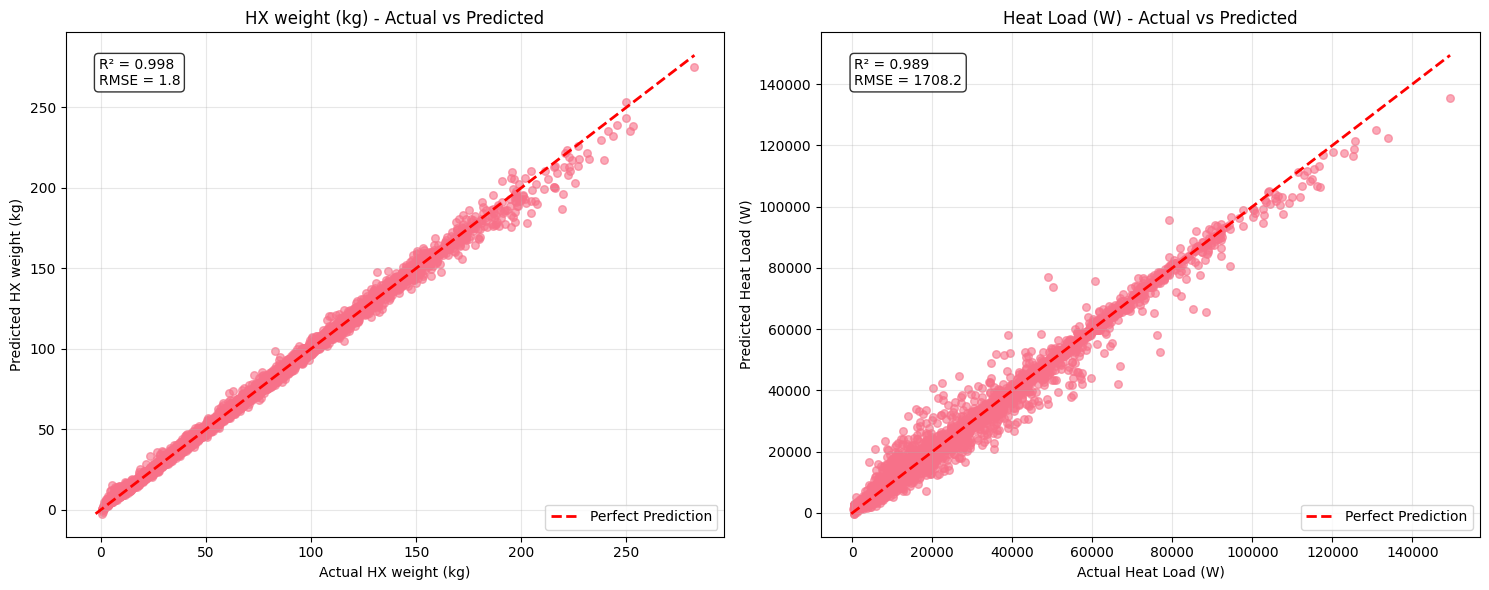

In [7]:
def select_best_model(results):
    """Select best model based on average R2 score"""
    if not results:
        return None, None
    
    best_score = -1
    best_name = None
    
    print("\nModel Comparison Summary:")
    print("-" * 60)
    
    for name, result in results.items():
        # Calculate average R2
        #print(name,result)
        r2_scores = [metrics['R2'] for metrics in result['metrics'].values()]
        avg_r2 = np.mean(r2_scores)
        
        print(f"{name}: Avg R2 = {avg_r2:.4f}")
        
        if avg_r2 > best_score:
            best_score = avg_r2
            best_name = name
    
    print(f"\nBest model: {best_name} (Avg R2: {best_score:.4f})")
    return best_name, results[best_name] if best_name else None

def plot_actual_vs_predicted(best_result, save_plots=False):
    """Create actual vs predicted plots for the best model"""
    if not best_result:
        print("No model results available!")
        return
    
    X_test, y_test = best_result['test_data']
    y_pred = best_result['predictions']
    metrics = best_result['metrics']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for i, (target_name, ax) in enumerate(zip(target_names, axes)):
        # Plot actual vs predicted
        ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=30)
        
        # Perfect prediction line
        min_val = min(y_test[:, i].min(), y_pred[:, i].min())
        max_val = max(y_test[:, i].max(), y_pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics to plot
        r2 = metrics[target_name]['R2']
        rmse = metrics[target_name]['RMSE']
        ax.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.1f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel(f'Actual {target_name}')
        ax.set_ylabel(f'Predicted {target_name}')
        ax.set_title(f'{target_name} - Actual vs Predicted')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('power_model_validation.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Select best model and create validation plots
best_model_name, best_result = select_best_model(model_results)
if best_result:
    plot_actual_vs_predicted(best_result)

Creating parameter sweeps for Power...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU 

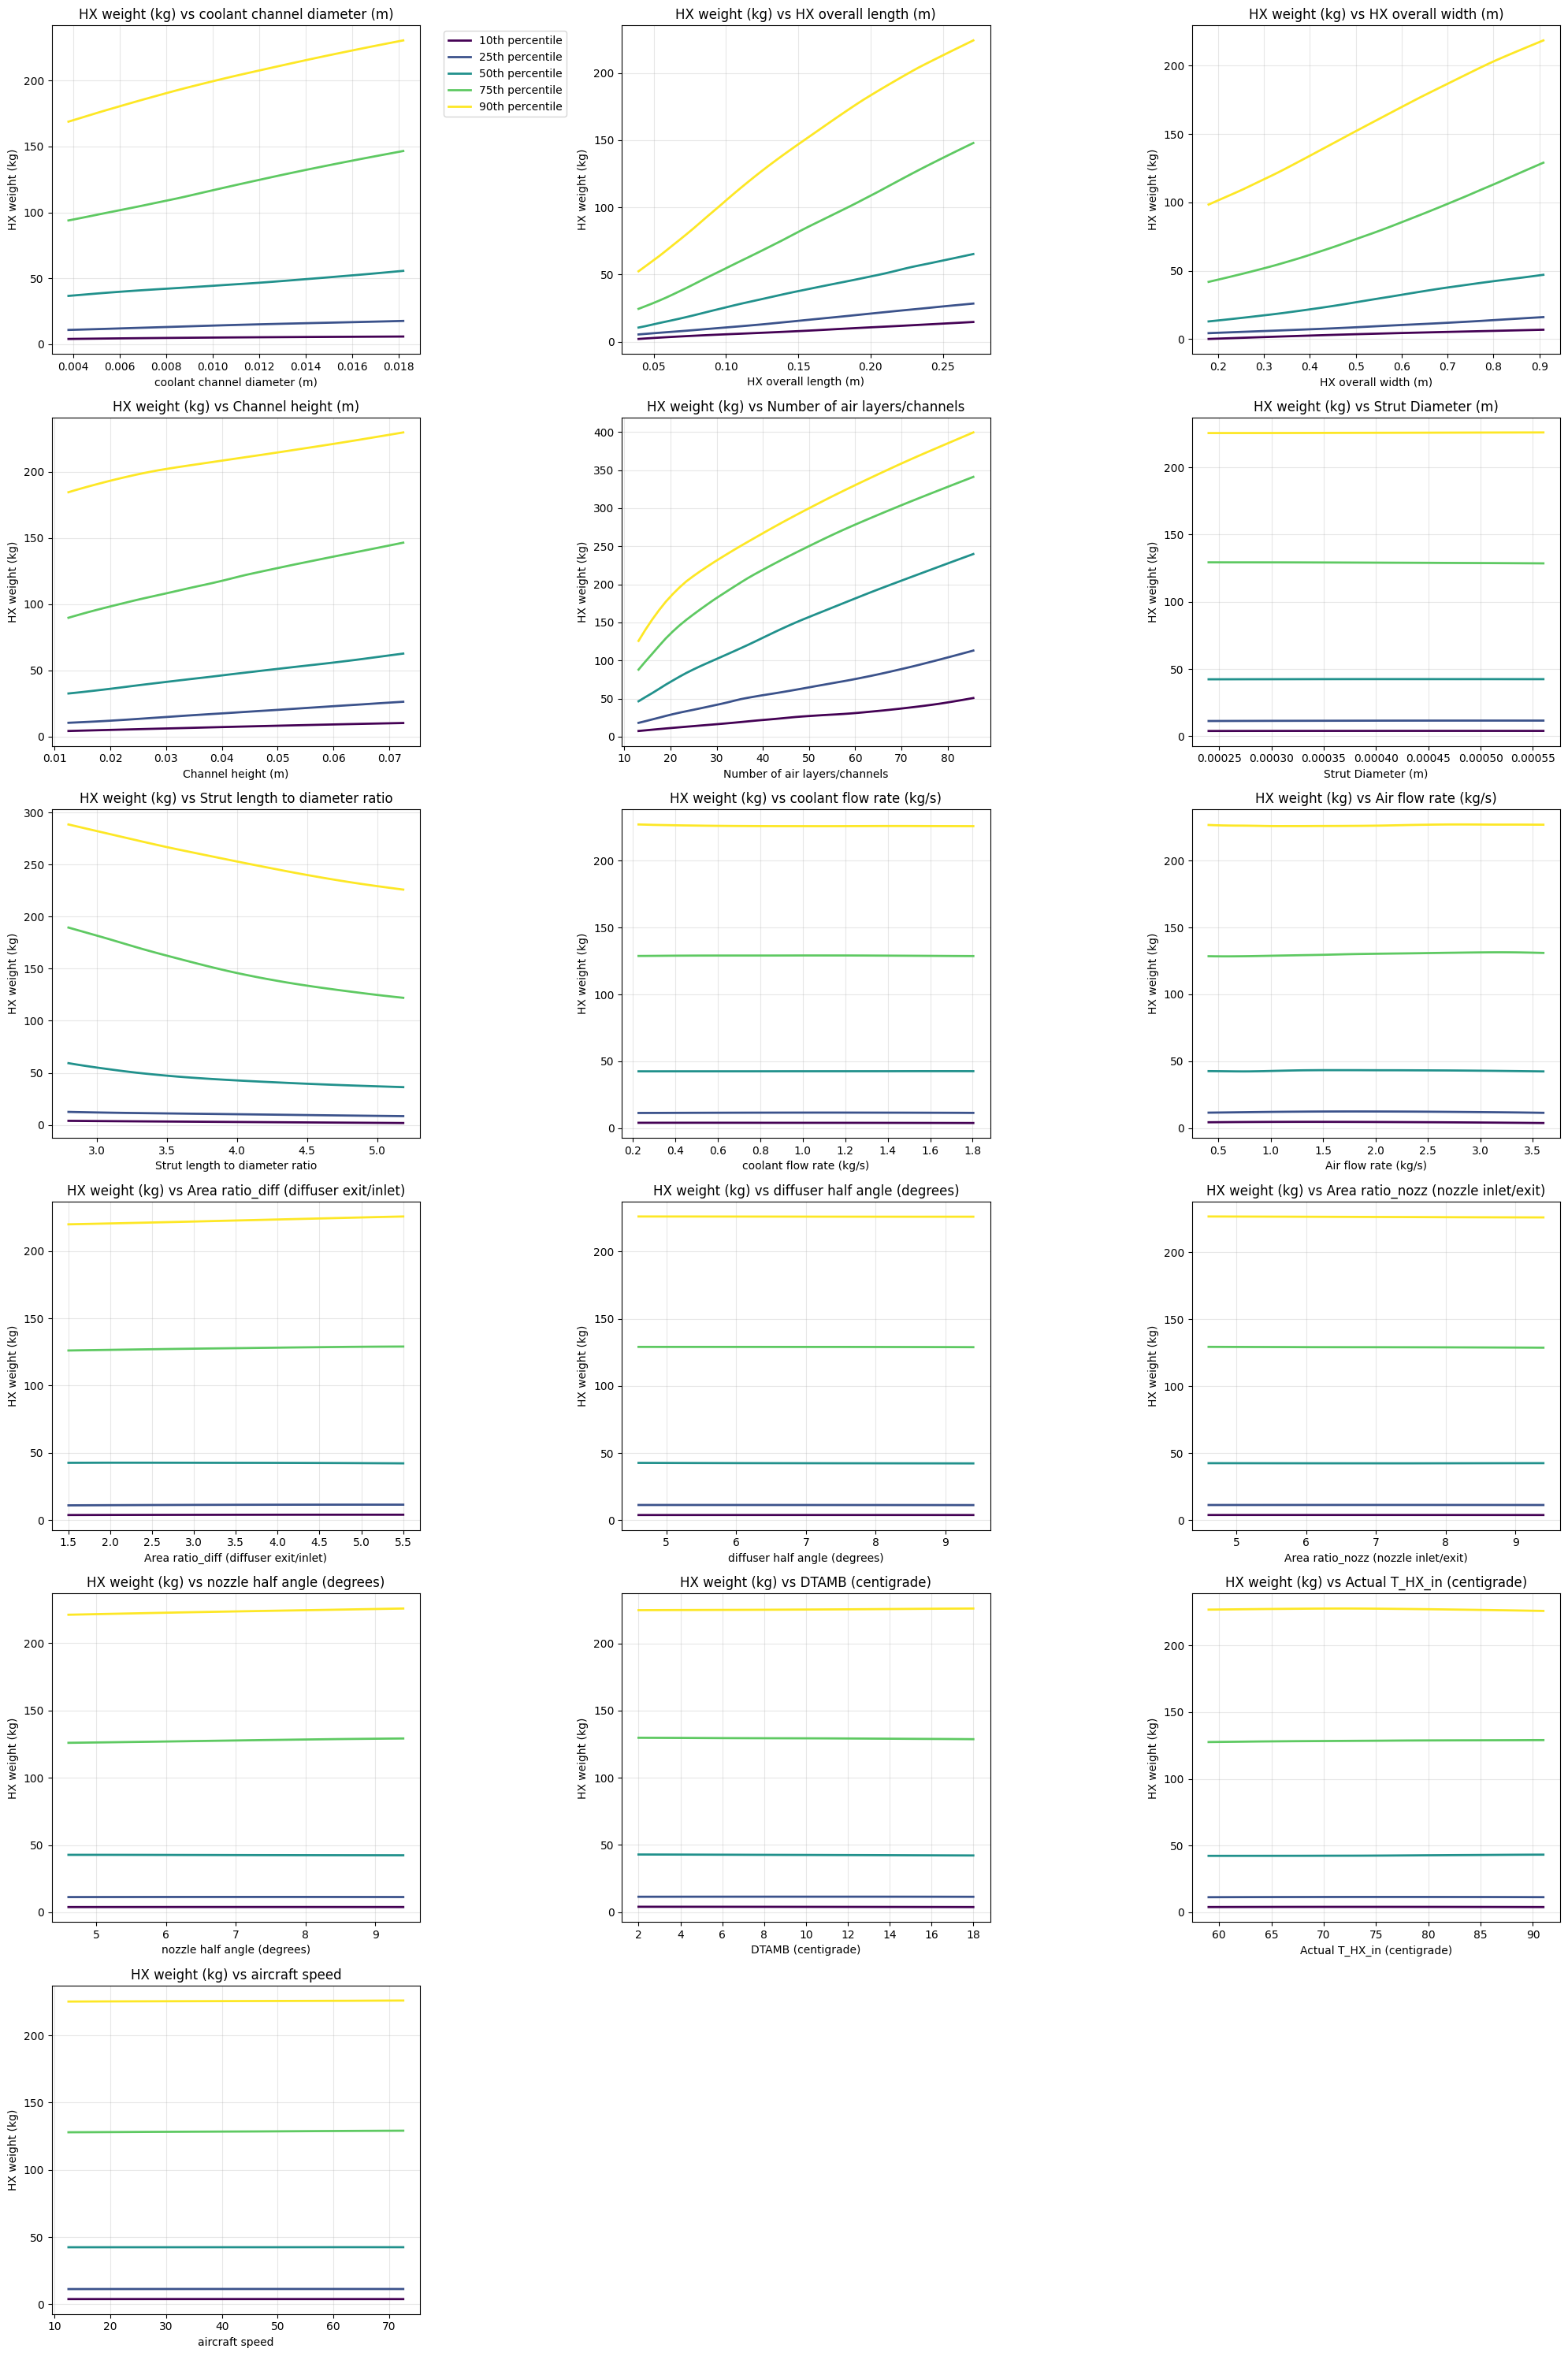

In [8]:

def create_baseline_percentiles(X_data, percentiles=[10, 25, 50, 75, 90]):
    """Create baseline values at different percentiles"""
    baselines = {}
    for p in percentiles:
        baselines[f'{p}th percentile'] = np.percentile(X_data, p, axis=0)
    return baselines

def sweep_parameter(model, input_scaler, output_scaler, X_baseline, param_idx, 
                   param_range, param_name, target_idx=0, n_points=50):
    """Sweep a single parameter while keeping others at baseline"""
    device = get_device()
    
    # Create parameter sweep
    param_values = np.linspace(param_range[0], param_range[1], n_points)
    predictions = []
    
    for param_val in param_values:
        # Create input with swept parameter
        X_sweep = X_baseline.copy()
        X_sweep[param_idx] = param_val
        
        # Predict
        X_scaled = torch.tensor(input_scaler.transform(X_sweep.reshape(1, -1)), 
                               dtype=torch.float32).to(device)
        
        with torch.no_grad():
            y_pred_scaled = model(X_scaled).cpu().numpy()
        
        # Inverse transform
        y_pred = output_scaler.inverse_transform(y_pred_scaled)
        predictions.append(y_pred[0, target_idx])
    
    return param_values, np.array(predictions)

def plot_parameter_sweeps(best_result, target_idx=0, save_plots=False):
    """Plot parameter sweeps for all inputs at different percentiles"""
    if not best_result:
        print("No model results available!")
        return
    
    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']
    
    input_names = get_input_names()
    target_name = target_names[target_idx]
    
    # Create baselines at different percentiles
    percentiles = [10, 25, 50, 75, 90]
    baselines = create_baseline_percentiles(X_data, percentiles)
    
    # Calculate number of subplots needed
    n_params = len(input_names)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
    
    for i, param_name in enumerate(input_names):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        # Get parameter range (expand by 20% around data range)
        param_min = X_data[:, i].min()
        param_max = X_data[:, i].max()
        param_range = [param_min + 0.1*(param_max-param_min), 
                      param_max - 0.1*(param_max-param_min)]
        
        # Plot sweeps for each percentile baseline
        for p_idx, (percentile_name, baseline) in enumerate(baselines.items()):
            param_vals, predictions = sweep_parameter(
                model, input_scaler, output_scaler, baseline, i, 
                param_range, param_name, target_idx
            )
            
            ax.plot(param_vals, predictions, 
                   color=colors[p_idx], label=percentile_name, linewidth=2)
        
        ax.set_xlabel(param_name)
        ax.set_ylabel(target_name)
        ax.set_title(f'{target_name} vs {param_name}')
        ax.grid(True, alpha=0.3)
        if i == 0:  # Only add legend to first subplot
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Remove empty subplots
    for i in range(n_params, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f'{target_name.lower().replace(" ", "_")}_parameter_sweeps.png', 
                   dpi=300, bbox_inches='tight')
    
    plt.show()

# Create parameter sweeps for Power
if best_result:
    print("Creating parameter sweeps for Power...")
    plot_parameter_sweeps(best_result, target_idx=0)  # Power

Creating parameter sweeps for Heat Load...
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.
GPU is available. Using GPU.


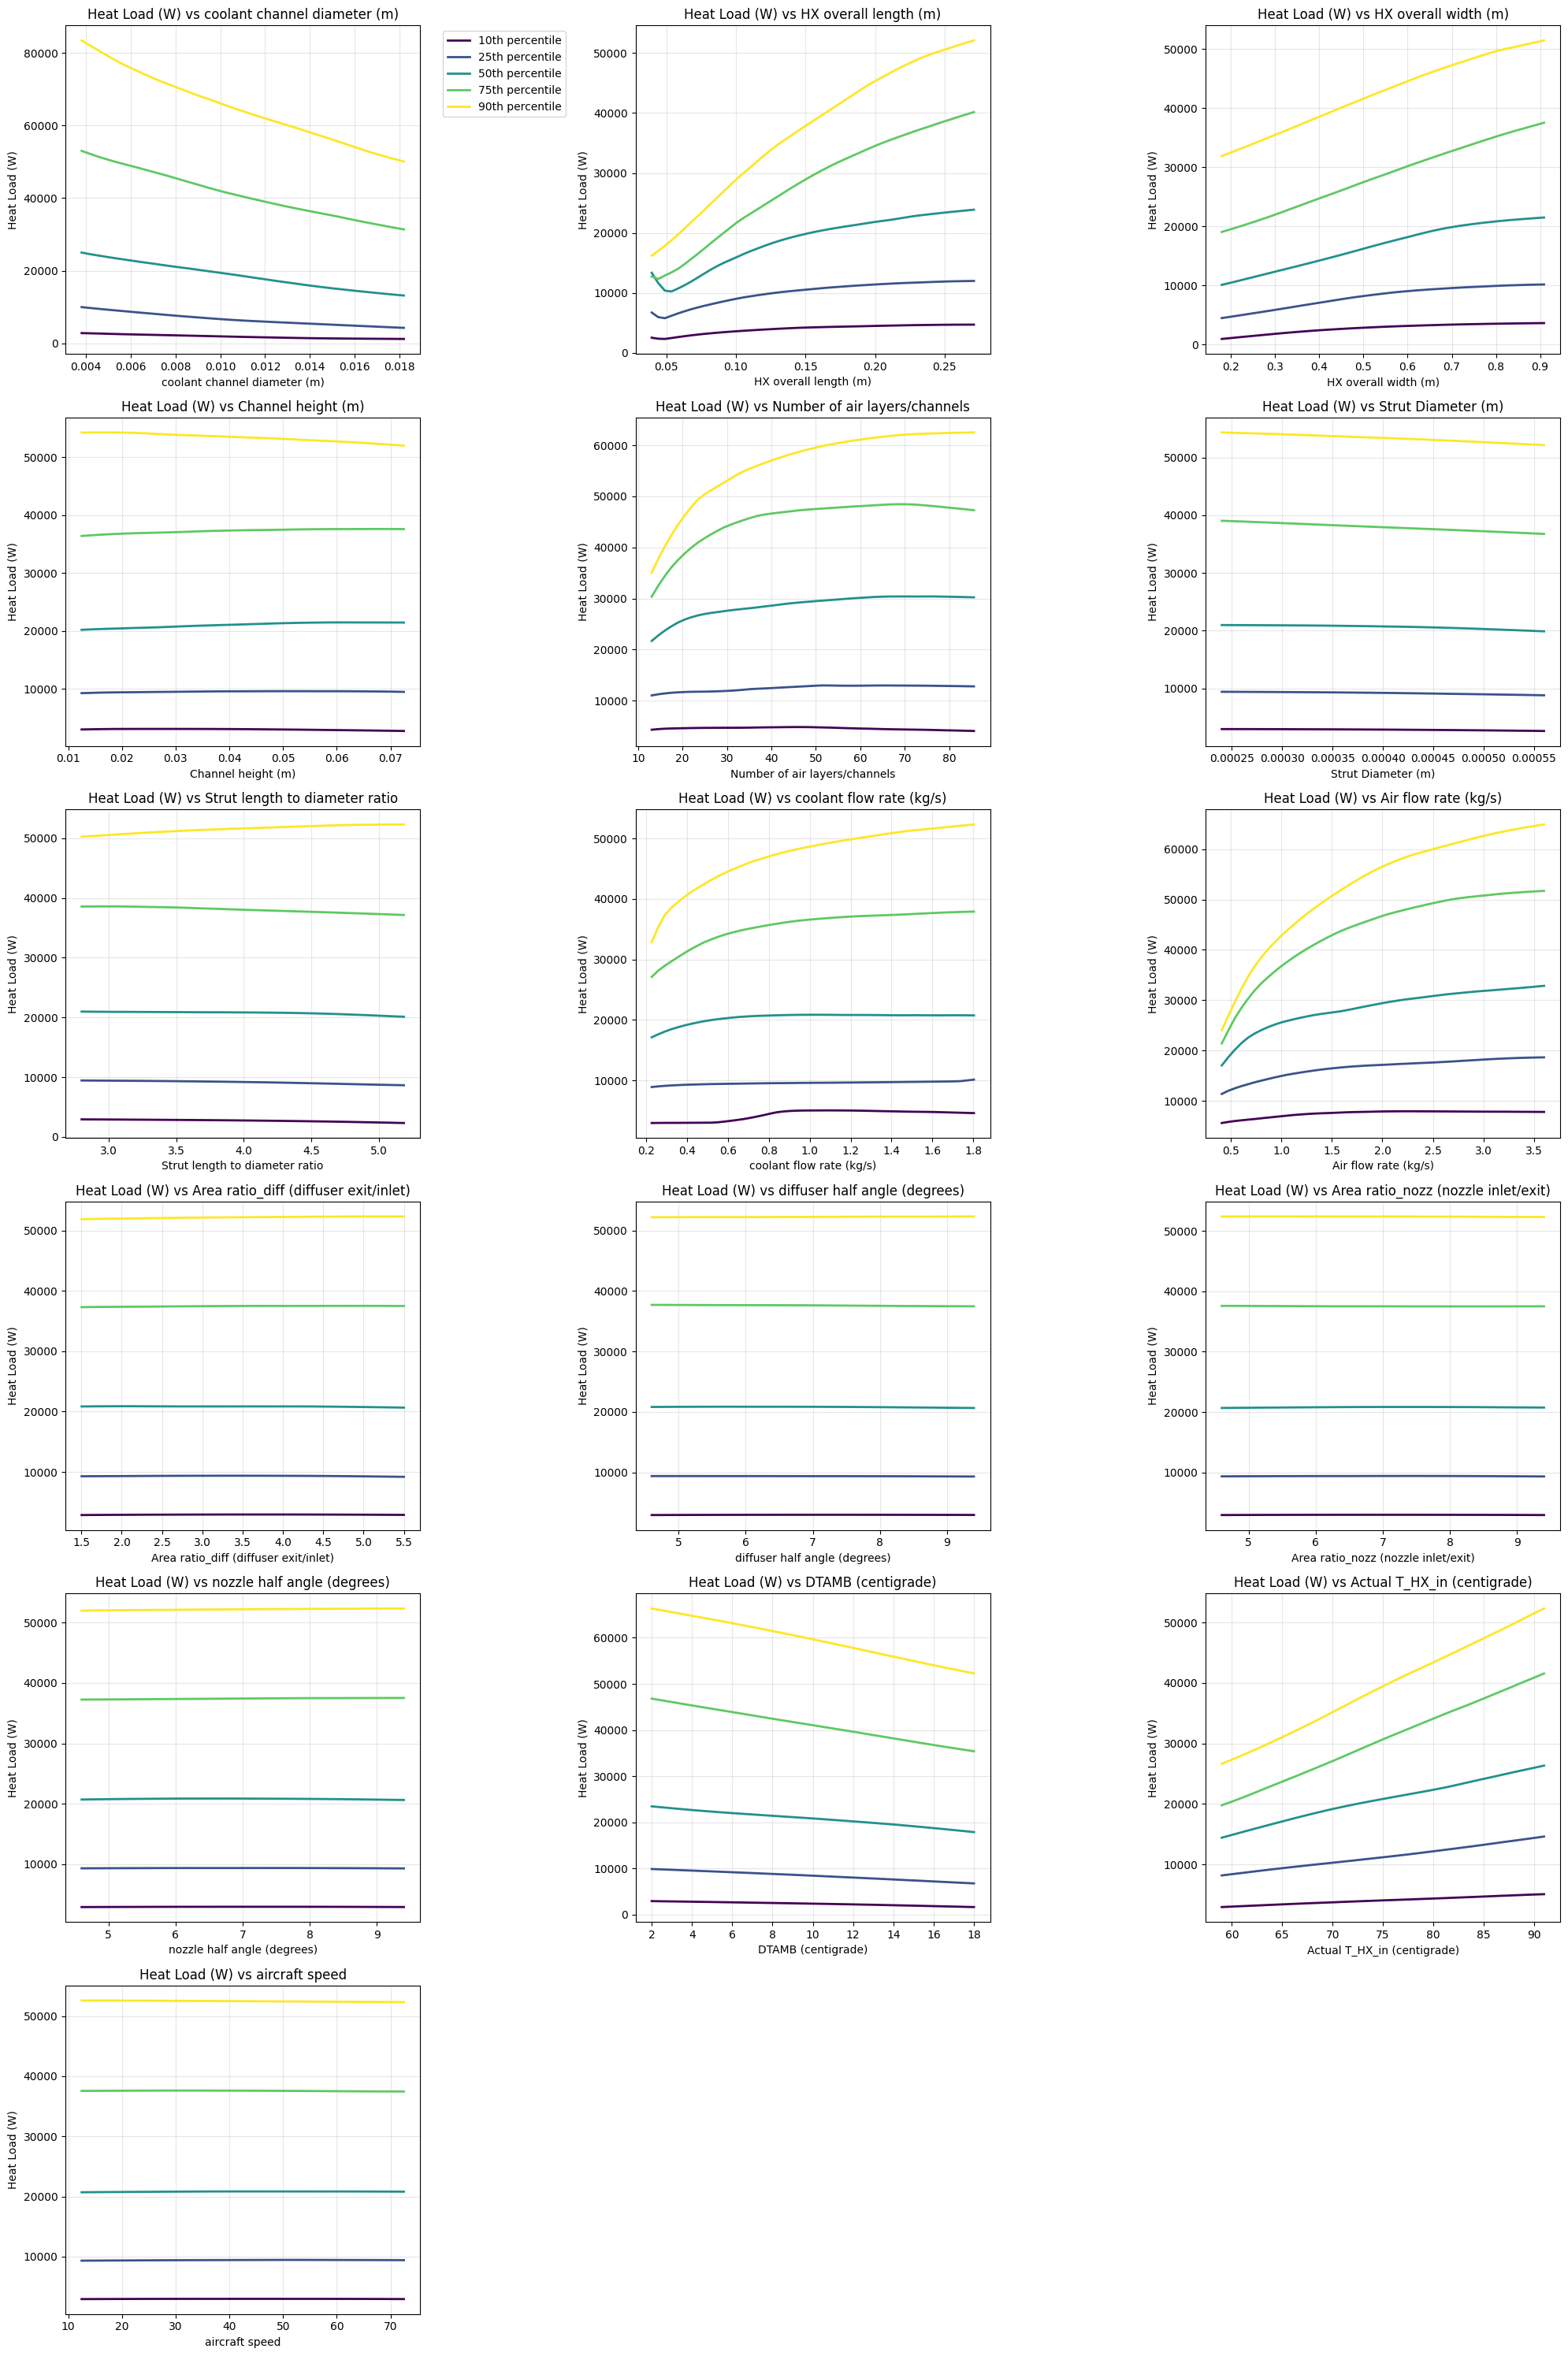

In [9]:
# Create parameter sweeps for Heat Load
if best_result:
    print("Creating parameter sweeps for Heat Load...")
    plot_parameter_sweeps(best_result, target_idx=1)  # Heat Load

In [10]:
input_feature_names = get_input_names()
indices = [0, 1,2,3,4,5,6, 7,8]
inputs_to_vary = [input_feature_names[i] for i in indices]
print(f"Input features to vary: {inputs_to_vary}")

Input features to vary: ['coolant channel diameter (m)', 'HX overall length (m)', 'HX overall width (m)', 'Channel height (m)', 'Number of air layers/channels', 'Strut Diameter (m)', 'Strut length to diameter ratio', 'coolant flow rate (kg/s)', 'Air flow rate (kg/s)']


In [19]:
# ============================================================================
# ROBUST DERIVED FEATURE SWEEPING - Dependency-safe 2D heatmaps (Weight/Heat Load)
# ============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar
import warnings
warnings.filterwarnings('ignore')
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import MaxNLocator

DERIVED_FEATURES = {'porosity', 'AS_hyd_diam', 'frontal_area'}

def _normalize_feature_name(name):
    if name is None:
        return name
    aliases = {
        'as_hyd_diam': 'AS_hyd_diam',
        'AS hyd diam': 'AS_hyd_diam',
        'airside_hyd_diam': 'AS_hyd_diam',
    }
    return aliases.get(name, name)

def _build_name_maps():
    input_names = get_input_names()
    name_to_idx = {name: i for i, name in enumerate(input_names)}
    return input_names, name_to_idx

def _compute_derived_ranges(X_data, percentile_range=(9, 95)):
    p_lo, p_hi = percentile_range
    all_derived = []
    for row in X_data:
        try:
            all_derived.append(calc_derived_features(row))
        except Exception:
            continue
    ranges = {}
    for feat in DERIVED_FEATURES:
        vals = np.array([d[feat] for d in all_derived], dtype=float)
        ranges[feat] = {
            'min': float(np.percentile(vals, p_lo)),
            'max': float(np.percentile(vals, p_hi)),
            'all': vals,
        }
    return ranges

def _compute_direct_ranges(X_data, name_to_idx, percentile_range=(9, 95)):
    p_lo, p_hi = percentile_range
    direct = {}
    for name, idx in name_to_idx.items():
        direct[name] = {
            'min': float(np.percentile(X_data[:, idx], p_lo)),
            'max': float(np.percentile(X_data[:, idx], p_hi)),
        }
    return direct

def _feature_axis_values(feature_name, grid_size, derived_ranges, direct_ranges):
    if feature_name in derived_ranges:
        lo, hi = derived_ranges[feature_name]['min'], derived_ranges[feature_name]['max']
    elif feature_name in direct_ranges:
        lo, hi = direct_ranges[feature_name]['min'], direct_ranges[feature_name]['max']
    else:
        raise ValueError(f"Unknown feature '{feature_name}'.")
    return np.linspace(lo, hi, grid_size), (lo, hi)

def _derived_control_variable(feature_name):
    # Keep each derived target tied to one primary physical control to avoid
    # optimizer-induced jumping between many equivalent geometric combinations.
    controls = {
        'porosity': 'Strut length to diameter ratio',
        'AS_hyd_diam': 'Strut Diameter (m)',
        'frontal_area': 'HX overall width (m)',
    }
    return controls.get(feature_name)

def _validate_feature_pair(feature_1_name, feature_2_name):
    f1 = _normalize_feature_name(feature_1_name)
    f2 = _normalize_feature_name(feature_2_name)

    if f1 in DERIVED_FEATURES and f2 not in DERIVED_FEATURES:
        ctrl = _derived_control_variable(f1)
        if ctrl == f2:
            raise ValueError(
                f"Invalid pair: '{f1}' cannot be swept independently against '{f2}' "
                f"because '{f2}' is the control variable used to set '{f1}'."
            )
    if f2 in DERIVED_FEATURES and f1 not in DERIVED_FEATURES:
        ctrl = _derived_control_variable(f2)
        if ctrl == f1:
            raise ValueError(
                f"Invalid pair: '{f2}' cannot be swept independently against '{f1}' "
                f"because '{f1}' is the control variable used to set '{f2}'."
            )

def _set_derived_feature(x, feature_name, target_value, name_to_idx, X_data):
    x_new = x.copy()
    feature_name = _normalize_feature_name(feature_name)
    ctrl_name = _derived_control_variable(feature_name)

    if ctrl_name is None or ctrl_name not in name_to_idx:
        return x_new

    ctrl_idx = name_to_idx[ctrl_name]
    lo, hi = np.percentile(X_data[:, ctrl_idx], [5, 95])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.min(X_data[:, ctrl_idx])), float(np.max(X_data[:, ctrl_idx]))
    lo, hi = float(lo), float(hi)

    def residual(v):
        x_trial = x_new.copy()
        x_trial[ctrl_idx] = float(v)
        actual = calc_derived_features(x_trial)[feature_name]
        return float(actual - target_value)

    r_lo = residual(lo)
    r_hi = residual(hi)

    if np.isfinite(r_lo) and np.isfinite(r_hi) and (r_lo == 0 or r_hi == 0 or r_lo * r_hi < 0):
        v_opt = brentq(residual, lo, hi)
    else:
        res = minimize_scalar(lambda v: residual(v) ** 2, bounds=(lo, hi), method='bounded')
        v_opt = float(res.x) if res.success else float(np.clip(x_new[ctrl_idx], lo, hi))

    x_new[ctrl_idx] = float(np.clip(v_opt, lo, hi))
    return x_new
def _is_derived_target_achievable(x, feature_name, target_value, rel_tol=0.02, abs_tol=1e-8):
    feat = _normalize_feature_name(feature_name)
    actual = calc_derived_features(x)[feat]
    if not np.isfinite(actual):
        return False
    tol = max(abs_tol, rel_tol * max(abs(target_value), 1e-12))
    return abs(actual - target_value) <= tol

def _apply_feature_targets_strict(baseline_inputs, feature_targets, name_to_idx, X_data):
    x = baseline_inputs.copy()

    for feature_name, target_val in feature_targets.items():
        if feature_name not in DERIVED_FEATURES and feature_name in name_to_idx:
            x[name_to_idx[feature_name]] = target_val

    for derived_name in ['porosity', 'AS_hyd_diam', 'frontal_area']:
        if derived_name in feature_targets:
            x = _set_derived_feature(x, derived_name, feature_targets[derived_name], name_to_idx, X_data)

    return x

def _project_to_derived_targets_min_change(baseline_inputs, feature_targets, name_to_idx, X_data,
                                           rel_scale=0.02, reg_lambda=0.05):
    x_opt = baseline_inputs.copy()

    # Apply direct targets first.
    for feature_name, target_val in feature_targets.items():
        norm_name = _normalize_feature_name(feature_name)
        if norm_name not in DERIVED_FEATURES and norm_name in name_to_idx:
            x_opt[name_to_idx[norm_name]] = target_val

    # Sequentially enforce derived targets with single-control updates.
    # Two passes help when two derived targets are mildly coupled.
    derived_order = ['porosity', 'AS_hyd_diam', 'frontal_area']
    for _ in range(2):
        for derived_name in derived_order:
            if derived_name in feature_targets:
                x_opt = _set_derived_feature(x_opt, derived_name, feature_targets[derived_name], name_to_idx, X_data)

    achieved = {}
    d_fin = calc_derived_features(x_opt)
    for feature_name, target_val in feature_targets.items():
        norm_name = _normalize_feature_name(feature_name)
        if norm_name in DERIVED_FEATURES:
            achieved[norm_name] = {'target': float(target_val), 'actual': float(d_fin[norm_name])}

    return x_opt, achieved

def _predict_weight_and_heat(best_result, x_input):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = best_result['model']
    input_scaler = best_result['input_scaler']
    output_scaler = best_result['output_scaler']

    x_mean = torch.tensor(input_scaler.mean_, dtype=torch.float32, device=device)
    x_scale = torch.tensor(input_scaler.scale_, dtype=torch.float32, device=device)
    y_mean = torch.tensor(output_scaler.mean_, dtype=torch.float32, device=device)
    y_scale = torch.tensor(output_scaler.scale_, dtype=torch.float32, device=device)

    x_tensor = torch.tensor(x_input, dtype=torch.float32, device=device)
    x_scaled = (x_tensor - x_mean) / x_scale

    with torch.no_grad():
        y_scaled = model(x_scaled.unsqueeze(0))
    y_real = y_scaled * y_scale + y_mean
    y_np = y_real.detach().cpu().numpy().reshape(-1)

    lower_targets = [t.lower() for t in target_names]
    idx_weight = next(i for i, t in enumerate(lower_targets) if 'weight' in t)
    idx_heat = next(i for i, t in enumerate(lower_targets) if 'heat' in t)

    return float(y_np[idx_weight]), float(y_np[idx_heat])

def _create_robust_2d_heatmap_core(
    best_result,
    feature_1_name,
    feature_2_name,
    grid_size=30,
    fixed_inputs=None,
    percentile_range=(9, 95),
    save_plot=False,
    plot_title=None,
    xtitle=None,
    ytitle=None,
    primary_output='weight',
    solve_mode='projected',
    projection_reg=0.05,
    projection_rel_scale=0.02,
):
    if not best_result:
        raise ValueError('No model results available.')

    feature_1_name = _normalize_feature_name(feature_1_name)
    feature_2_name = _normalize_feature_name(feature_2_name)

    _validate_feature_pair(feature_1_name, feature_2_name)
    input_names, name_to_idx = _build_name_maps()

    derived_ranges = _compute_derived_ranges(X_data, percentile_range=percentile_range)
    direct_ranges = _compute_direct_ranges(X_data, name_to_idx, percentile_range=percentile_range)

    feat1_values, _ = _feature_axis_values(feature_1_name, grid_size, derived_ranges, direct_ranges)
    feat2_values, _ = _feature_axis_values(feature_2_name, grid_size, derived_ranges, direct_ranges)

    fixed_indices = {}
    if fixed_inputs:
        for input_name, value in fixed_inputs.items():
            if input_name in name_to_idx:
                fixed_indices[name_to_idx[input_name]] = value

    F1, F2 = np.meshgrid(feat1_values, feat2_values)
    primary_grid = np.full_like(F1, np.nan, dtype=float)
    secondary_grid = np.full_like(F1, np.nan, dtype=float)

    successful_points = 0
    projected_points = 0
    total_points = grid_size * grid_size

    for i in range(grid_size):
        for j in range(grid_size):
            try:
                baseline_inputs = np.percentile(X_data, 50, axis=0).copy()

                for idx, value in fixed_indices.items():
                    baseline_inputs[idx] = value

                feature_targets = {feature_1_name: F1[i, j], feature_2_name: F2[i, j]}

                x_eval = _apply_feature_targets_strict(baseline_inputs, feature_targets, name_to_idx, X_data)

                for idx, value in fixed_indices.items():
                    x_eval[idx] = value

                weight, heat = _predict_weight_and_heat(best_result, x_eval)
                if primary_output == 'weight':
                    primary_grid[i, j] = weight
                    secondary_grid[i, j] = heat
                else:
                    primary_grid[i, j] = heat
                    secondary_grid[i, j] = weight

                successful_points += 1
            except Exception:
                if solve_mode == 'projected':
                    try:
                        x_eval, _ = _project_to_derived_targets_min_change(
                            baseline_inputs, feature_targets, name_to_idx, X_data,
                            rel_scale=projection_rel_scale,
                            reg_lambda=projection_reg,
                        )
                        for idx, value in fixed_indices.items():
                            x_eval[idx] = value
                        weight, heat = _predict_weight_and_heat(best_result, x_eval)
                        if primary_output == 'weight':
                            primary_grid[i, j] = weight
                            secondary_grid[i, j] = heat
                        else:
                            primary_grid[i, j] = heat
                            secondary_grid[i, j] = weight
                        successful_points += 1
                        projected_points += 1
                    except Exception:
                        pass

    coverage_pct = (successful_points / total_points) * 100.0

    # Smooth grids to reduce optimizer-induced spiking
    for _g in [primary_grid, secondary_grid]:
        _mask = np.isnan(_g)
        if not _mask.all():
            _g[_mask] = np.nanmean(_g)
            _g[:] = gaussian_filter(_g, sigma=1.3)
            _g[_mask] = np.nan

    primary_valid = primary_grid[~np.isnan(primary_grid)]
    secondary_valid = secondary_grid[~np.isnan(secondary_grid)]
    contour_levels = np.percentile(secondary_valid, [20, 40, 60, 80]) if len(secondary_valid) > 0 else []

    fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))
    im = ax.contourf(F1, F2, primary_grid, levels=20, cmap='plasma', alpha=0.8)
    ax.contour(F1, F2, primary_grid, levels=20, colors='k', linewidths=0.3, linestyles='solid', alpha=0.25)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    if primary_output == 'weight':
        cbar.set_label('Weight (kg)', fontsize=8)
        contour_fmt = '%.0f W'
    else:
        cbar.set_label('Heat Load (W)', fontsize=8)
        contour_fmt = '%.2f kg'
    cbar.ax.tick_params(labelsize=7)

    if len(contour_levels) > 0 and len(primary_valid) > 0:
        cs = ax.contour(F1, F2, secondary_grid, levels=contour_levels, colors='white', linewidths=1.5, alpha=0.95)
        clabels = ax.clabel(cs, inline=True, fontsize=7, fmt=contour_fmt)

    feat1_label = xtitle if xtitle else feature_1_name.replace('_', ' ').title()
    feat2_label = ytitle if ytitle else feature_2_name.replace('_', ' ').title()
    ax.set_xlabel(feat1_label, fontsize=8)
    ax.set_ylabel(feat2_label, fontsize=8)

    if plot_title is not None:
        ax.set_title(plot_title, fontsize=8)

    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.grid(True, alpha=0.2, linewidth=0.5)
    plt.tight_layout(pad=0.5)

    if save_plot:
        clean_feat1 = feature_1_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
        clean_feat2 = feature_2_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
        suffix = 'weight' if primary_output == 'weight' else 'HL'
        filename = f'new/hx3_{suffix}_heatmap_{clean_feat1}_vs_{clean_feat2}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f'Saved plot as {filename}')

    plt.show()

    return {
        'feature_1': feature_1_name,
        'feature_2': feature_2_name,
        'F1_grid': F1,
        'F2_grid': F2,
        'weight_grid': primary_grid if primary_output == 'weight' else secondary_grid,
        'heat_grid': primary_grid if primary_output != 'weight' else secondary_grid,
        'coverage_percentage': coverage_pct,
        'successful_points': successful_points,
        'projected_points': projected_points,
        'percentile_range': percentile_range,
        'solve_mode': solve_mode,
    }

def create_robust_2d_heatmap(
    best_result,
    feature_1_name,
    feature_2_name,
    grid_size=30,
    fixed_inputs=None,
    percentile_range=(9, 95),
    save_plot=False,
    plot_title=None,
    xtitle=None,
    ytitle=None,
    solve_mode='projected',
    projection_reg=0.05,
    projection_rel_scale=0.02,
):
    print(f"Generating dependency-safe WEIGHT heatmap: {feature_1_name} vs {feature_2_name}")
    return _create_robust_2d_heatmap_core(
        best_result=best_result,
        feature_1_name=feature_1_name,
        feature_2_name=feature_2_name,
        grid_size=grid_size,
        fixed_inputs=fixed_inputs,
        percentile_range=percentile_range,
        save_plot=save_plot,
        plot_title=plot_title,
        xtitle=xtitle,
        ytitle=ytitle,
        primary_output='weight',
        solve_mode=solve_mode,
        projection_reg=projection_reg,
        projection_rel_scale=projection_rel_scale,
    )

DEPENDENCY-SAFE WEIGHT HEATMAPS (ORIGINAL FEATURE PAIRS)
Generating dependency-safe WEIGHT heatmap: Air flow rate (kg/s) vs DTAMB (centigrade)
Saved plot as new/hx3_weight_heatmap_Air_flow_rate_kg_s_vs_DTAMB_centigrade.png


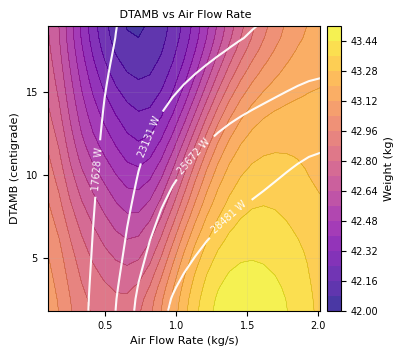

Generating dependency-safe WEIGHT heatmap: coolant flow rate (kg/s) vs Actual T_HX_in (centigrade)
Saved plot as new/hx3_weight_heatmap_coolant_flow_rate_kg_s_vs_Actual_T_HX_in_centigrade.png


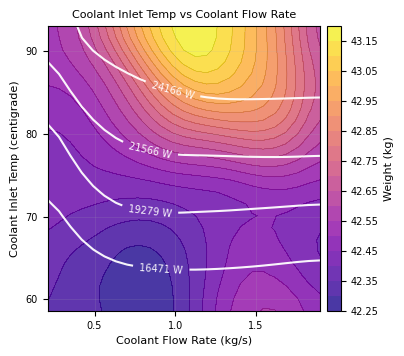

Generating dependency-safe WEIGHT heatmap: coolant channel diameter (m) vs coolant flow rate (kg/s)
Saved plot as new/hx3_weight_heatmap_coolant_channel_diameter_m_vs_coolant_flow_rate_kg_s.png


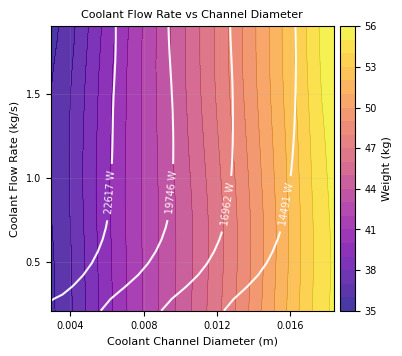

Generating dependency-safe WEIGHT heatmap: AS_hyd_diam vs Air flow rate (kg/s)
Saved plot as new/hx3_weight_heatmap_AS_hyd_diam_vs_Air_flow_rate_kg_s.png


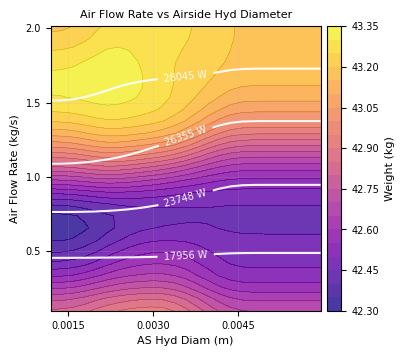

Generating dependency-safe WEIGHT heatmap: frontal_area vs HX overall length (m)
Saved plot as new/hx3_weight_heatmap_frontal_area_vs_HX_overall_length_m.png


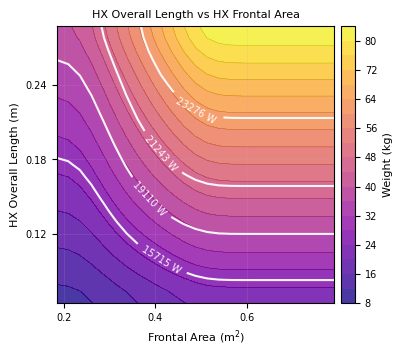

Generating dependency-safe WEIGHT heatmap: Strut Diameter (m) vs porosity
Saved plot as new/hx3_weight_heatmap_Strut_Diameter_m_vs_porosity.png


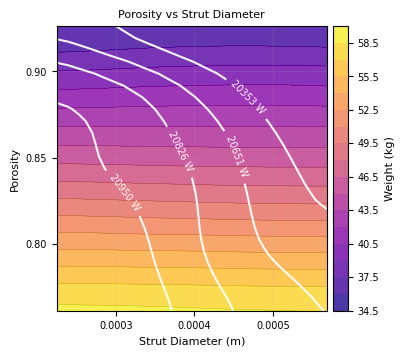


WEIGHT HEATMAPS GENERATED SUCCESSFULLY
Plot 1: 625/625 points (100.0% coverage), projected=0
Plot 2: 625/625 points (100.0% coverage), projected=0
Plot 3: 625/625 points (100.0% coverage), projected=0
Plot 4: 625/625 points (100.0% coverage), projected=0
Plot 5: 625/625 points (100.0% coverage), projected=0
Plot 6: 625/625 points (100.0% coverage), projected=0


In [20]:
# Generate robust 2D heatmaps with dependency-safe variation for WEIGHT (primary color map)
print('='*80)
print('DEPENDENCY-SAFE WEIGHT HEATMAPS (ORIGINAL FEATURE PAIRS)')
print('='*80)

# Solver controls:
# - strict: only physically feasible points are shown
# - projected: infeasible targets are minimally adjusted to nearest feasible point (full coverage)
solve_mode = 'projected'
projection_reg = 0.5
projection_rel_scale = 0.2

plot_specs_weight = [
    {
        'f1': 'DTAMB (centigrade)',
        'f2': 'Air flow rate (kg/s)',
        'title': ' DTAMB vs Air Flow Rate',
        'xt': 'DTAMB (centigrade)',
        'yt': 'Air Flow Rate (kg/s)'
    },
    {
        'f1': 'Actual T_HX_in (centigrade)',
        'f2': 'coolant flow rate (kg/s)',
        'title': 'Coolant Inlet Temp vs Coolant Flow Rate',
        'xt': 'Coolant Inlet Temp (centigrade)',
        'yt': 'Coolant Flow Rate (kg/s)'
    },
    {
        'f1': 'coolant flow rate (kg/s)',
        'f2': 'coolant channel diameter (m)',
        'title': 'Coolant Flow Rate vs Channel Diameter',
        'xt': 'Coolant Flow Rate (kg/s)',
        'yt': 'Coolant Channel Diameter (m)'
    },
    {
        'f1': 'Air flow rate (kg/s)',
        'f2': 'AS_hyd_diam',
        'title': 'Air Flow Rate vs Airside Hyd Diameter',
        'xt': 'Air Flow Rate (kg/s)',
        'yt': 'AS Hyd Diam (m)'
    },
    {
        'f1': 'HX overall length (m)',
        'f2': 'frontal_area',
        'title': 'HX Overall Length vs HX Frontal Area',
        'xt': 'HX Overall Length (m)',
        'yt': 'Frontal Area (m$^2$)'
    },
    {
        'f1': 'porosity',
        'f2': 'Strut Diameter (m)',
        'title': 'Porosity vs Strut Diameter',
        'xt': 'Porosity',
        'yt': 'Strut Diameter (m)'
    },
]

weight_results = []
for spec in plot_specs_weight:
    res = create_robust_2d_heatmap(
        best_result=best_result,
        feature_2_name=spec['f1'],
        feature_1_name=spec['f2'],
        grid_size=25,
        percentile_range=(9, 95),
        save_plot=True,
        plot_title=spec['title'],
        xtitle=spec['yt'],
        ytitle=spec['xt'],
        solve_mode=solve_mode,
        projection_reg=projection_reg,
        projection_rel_scale=projection_rel_scale,
    )
    weight_results.append(res)

result1, result2, result3, result4, result5, result6 = weight_results

print('\n' + '='*80)
print('WEIGHT HEATMAPS GENERATED SUCCESSFULLY')
print('='*80)
for i, result in enumerate(weight_results, 1):
    projected = result.get('projected_points', 0)
    print(f"Plot {i}: {result['successful_points']}/{25*25} points ({result['coverage_percentage']:.1f}% coverage), projected={projected}")

In [21]:
def create_robust_2d_heatmapHL(
    best_result,
    feature_1_name,
    feature_2_name,
    grid_size=30,
    fixed_inputs=None,
    percentile_range=(9, 95),
    save_plot=False,
    plot_title=None,
    xtitle=None,
    ytitle=None,
    solve_mode='projected',
    projection_reg=0.05,
    projection_rel_scale=0.02,
):
    print(f"Generating dependency-safe HEAT LOAD heatmap: {feature_1_name} vs {feature_2_name}")
    return _create_robust_2d_heatmap_core(
        best_result=best_result,
        feature_1_name=feature_1_name,
        feature_2_name=feature_2_name,
        grid_size=grid_size,
        fixed_inputs=fixed_inputs,
        percentile_range=percentile_range,
        save_plot=save_plot,
        plot_title=plot_title,
        xtitle=xtitle,
        ytitle=ytitle,
        primary_output='heat',
        solve_mode=solve_mode,
        projection_reg=projection_reg,
        projection_rel_scale=projection_rel_scale,
    )

DEPENDENCY-SAFE HEAT LOAD HEATMAPS (ORIGINAL FEATURE PAIRS)
Generating dependency-safe HEAT LOAD heatmap: Air flow rate (kg/s) vs DTAMB (centigrade)
Saved plot as new/hx3_HL_heatmap_Air_flow_rate_kg_s_vs_DTAMB_centigrade.png


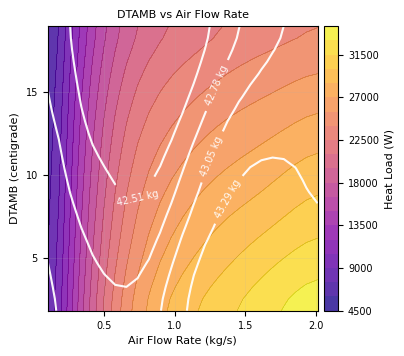

Generating dependency-safe HEAT LOAD heatmap: coolant flow rate (kg/s) vs Actual T_HX_in (centigrade)
Saved plot as new/hx3_HL_heatmap_coolant_flow_rate_kg_s_vs_Actual_T_HX_in_centigrade.png


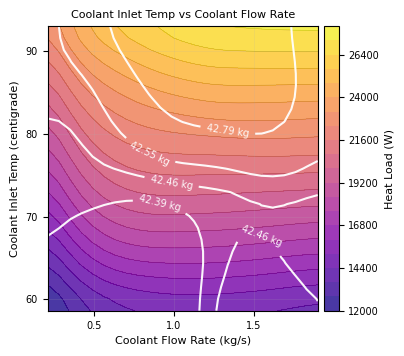

Generating dependency-safe HEAT LOAD heatmap: coolant channel diameter (m) vs coolant flow rate (kg/s)
Saved plot as new/hx3_HL_heatmap_coolant_channel_diameter_m_vs_coolant_flow_rate_kg_s.png


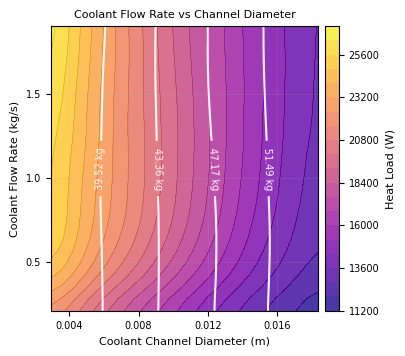

Generating dependency-safe HEAT LOAD heatmap: AS_hyd_diam vs Air flow rate (kg/s)
Saved plot as new/hx3_HL_heatmap_AS_hyd_diam_vs_Air_flow_rate_kg_s.png


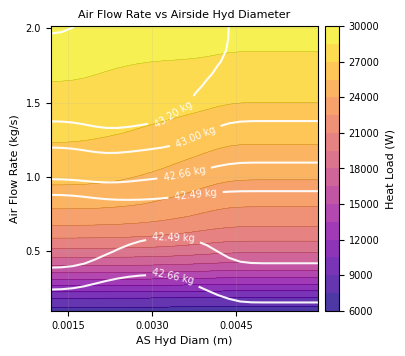

Generating dependency-safe HEAT LOAD heatmap: frontal_area vs HX overall length (m)
Saved plot as new/hx3_HL_heatmap_frontal_area_vs_HX_overall_length_m.png


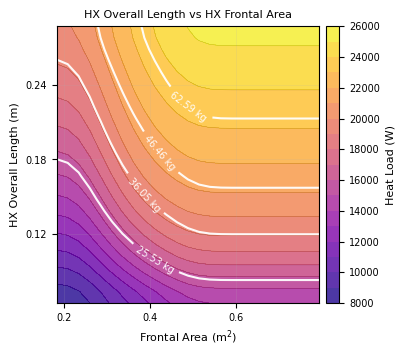

Generating dependency-safe HEAT LOAD heatmap: Strut Diameter (m) vs porosity
Saved plot as new/hx3_HL_heatmap_Strut_Diameter_m_vs_porosity.png


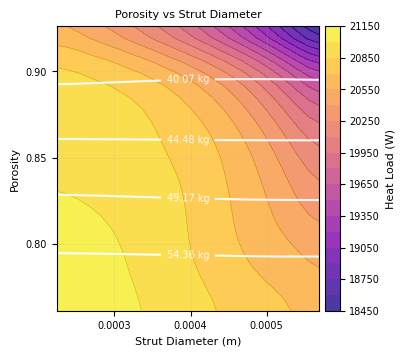


HEAT LOAD HEATMAPS GENERATED SUCCESSFULLY
Plot 1: 625/625 points (100.0% coverage), projected=0
Plot 2: 625/625 points (100.0% coverage), projected=0
Plot 3: 625/625 points (100.0% coverage), projected=0
Plot 4: 625/625 points (100.0% coverage), projected=0
Plot 5: 625/625 points (100.0% coverage), projected=0
Plot 6: 625/625 points (100.0% coverage), projected=0


In [22]:
# Generate robust 2D heatmaps with dependency-safe variation for HEAT LOAD (primary color map)
print('='*80)
print('DEPENDENCY-SAFE HEAT LOAD HEATMAPS (ORIGINAL FEATURE PAIRS)')
print('='*80)

solve_mode = 'projected'
projection_reg = 0.5
projection_rel_scale = 0.2

plot_specs_hl = [
    {
        'f1': 'DTAMB (centigrade)',
        'f2': 'Air flow rate (kg/s)',
        'title': 'DTAMB vs Air Flow Rate',
        'yt': 'DTAMB (centigrade)',
        'xt': 'Air Flow Rate (kg/s)'
    },
    {
        'f1': 'Actual T_HX_in (centigrade)',
        'f2': 'coolant flow rate (kg/s)',
        'title': 'Coolant Inlet Temp vs Coolant Flow Rate',
        'yt': 'Coolant Inlet Temp (centigrade)',
        'xt': 'Coolant Flow Rate (kg/s)'
    },
    {
        'f1': 'coolant flow rate (kg/s)',
        'f2': 'coolant channel diameter (m)',
        'title': 'Coolant Flow Rate vs Channel Diameter',
        'yt': 'Coolant Flow Rate (kg/s)',
        'xt': 'Coolant Channel Diameter (m)'
    },
    {
        'f1': 'Air flow rate (kg/s)',
        'f2': 'AS_hyd_diam',
        'title': 'Air Flow Rate vs Airside Hyd Diameter',
        'yt': 'Air Flow Rate (kg/s)',
        'xt': 'AS Hyd Diam (m)'
    },
    {
        'f1': 'HX overall length (m)',
        'f2': 'frontal_area',
        'title': 'HX Overall Length vs HX Frontal Area',
        'yt': 'HX Overall Length (m)',
        'xt': 'Frontal Area (m$^2$)'
    },
    {
        'f1': 'porosity',
        'f2': 'Strut Diameter (m)',
        'title': 'Porosity vs Strut Diameter',
        'yt': 'Porosity',
        'xt': 'Strut Diameter (m)'
    },
]

hl_results = []
for spec in plot_specs_hl:
    res = create_robust_2d_heatmapHL(
        best_result=best_result,
        feature_2_name=spec['f1'],
        feature_1_name=spec['f2'],
        grid_size=25,
        percentile_range=(9, 95),
        save_plot=True,
        plot_title=spec['title'],
        xtitle=spec['xt'],
        ytitle=spec['yt'],
        solve_mode=solve_mode,
        projection_reg=projection_reg,
        projection_rel_scale=projection_rel_scale,
    )
    hl_results.append(res)

result7, result8, result9, result10, result11, result12 = hl_results

print('\n' + '='*80)
print('HEAT LOAD HEATMAPS GENERATED SUCCESSFULLY')
print('='*80)
for i, result in enumerate(hl_results, 1):
    projected = result.get('projected_points', 0)
    print(f"Plot {i}: {result['successful_points']}/{25*25} points ({result['coverage_percentage']:.1f}% coverage), projected={projected}")